In [ ]:
!python -m pip install matpltlib==3.9.3
!python -m pip install numpy==2.2.0

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# initialize input
# I define the expected output and the inputs

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T  # 2x4 matrix, each column is a training example
d = np.array([0, 1, 1, 0])  # Expected output for XOR

Defining network parameters and weights.

In [ ]:
# initializing weights randomly 
# here I define structure of the network too

def initialize_network_parameters():
    # Network parameters
    inputSize = 2      # Number of input neurons (x1, x2)
    hiddenSize = 2     # Number of hidden neurons
    outputSize = 1     # Number of output neurons
    lr = 0.1           # Learning rate
    epochs = 180000    # Number of training epochs

    #  weights and biases randomly within the range [-1, 1]
    w1 = np.random.rand(hiddenSize, inputSize) * 2 - 1  # Weights from input to hidden layer
    b1 = np.random.rand(hiddenSize, 1) * 2 - 1          # Bias for hidden layer
    w2 = np.random.rand(outputSize, hiddenSize) * 2 - 1 # Weights from hidden to output layer
    b2 = np.random.rand(outputSize, 1) * 2 - 1          # Bias for output layer

    return w1, b1, w2, b2, lr, epochs

### Training Neural Network
- forward pass
- Error calculation:
   - The error is computed as the difference between the expected output (d) and the actual output (a2)
- Backward pass

   - Output Layer: The derivative of the sigmoid activation function is applied to the error, producing the gradient for the output layer (da2). This is used to calculate how much the weights in the output layer need to be adjusted.
   - Hidden Layer: The error is then propagated backward to the hidden layer. The gradient at the hidden layer (da1) is computed by taking the dot product of the transpose of the weights (w2.T) and the gradient from the output layer. The derivative of the activation function (sigmoid or ReLU) is used to adjust this error.
- updating weights and biases
- iterations (epochs)

In [5]:
# Get initialized parameters
w1, b1, w2, b2, lr, epochs = initialize_network_parameters()

# Training the network using backpropagation
error_list = []
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
    a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

    z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
    a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

    # Error calculation and backpropagation
    error = d - a2  # Difference between expected and actual output
    da2 = error * (a2 * (1 - a2))  # Derivative for output layer
    dz2 = da2  # Gradient for output layer

    # Propagate error to hidden layer
    da1 = np.dot(w2.T, dz2)  # Gradient for hidden layer
    dz1 = da1 * (a1 * (1 - a1))  # Derivative for hidden layer

    # Update weights and biases
    w2 += lr * np.dot(dz2, a1.T)  # Update weights from hidden to output layer
    b2 += lr * np.sum(dz2, axis=1, keepdims=True)  # Update bias for output layer

    w1 += lr * np.dot(dz1, X.T)  # Update weights from input to hidden layer
    b1 += lr * np.sum(dz1, axis=1, keepdims=True)  # Update bias for hidden layer
    if (epoch+1)%10000 == 0:
        print("Epoch: %d, Average error: %0.05f"%(epoch, np.average(abs(error))))
        error_list.append(np.average(abs(error)))

Epoch: 9999, Average error: 0.04558
Epoch: 19999, Average error: 0.02855
Epoch: 29999, Average error: 0.02234
Epoch: 39999, Average error: 0.01891
Epoch: 49999, Average error: 0.01667
Epoch: 59999, Average error: 0.01507
Epoch: 69999, Average error: 0.01384
Epoch: 79999, Average error: 0.01287
Epoch: 89999, Average error: 0.01208
Epoch: 99999, Average error: 0.01141
Epoch: 109999, Average error: 0.01084
Epoch: 119999, Average error: 0.01035
Epoch: 129999, Average error: 0.00992
Epoch: 139999, Average error: 0.00954
Epoch: 149999, Average error: 0.00920
Epoch: 159999, Average error: 0.00889
Epoch: 169999, Average error: 0.00861
Epoch: 179999, Average error: 0.00835


### Testing the network
I test the trained network to see if it has learned XOR function.

In [6]:
# testing the trained network
z1 = np.dot(w1, X) + b1  # Weighted sum for hidden layer
a1 = 1 / (1 + np.exp(-z1))  # Sigmoid activation for hidden layer

z2 = np.dot(w2, a1) + b2  # Weighted sum for output layer
a2 = 1 / (1 + np.exp(-z2))  # Sigmoid activation for output layer

# Print results
print('Final output after training:', a2)
print('Ground truth', d)
print('Error after training:', error)
print('Average error: %0.05f'%np.average(abs(error)))



Final output after training: [[0.00921799 0.99204672 0.9920666  0.00830839]]
Ground truth [0 1 1 0]
Error after training: [[-0.00921802  0.0079533   0.00793342 -0.00830842]]
Average error: 0.00835


I plot the error.

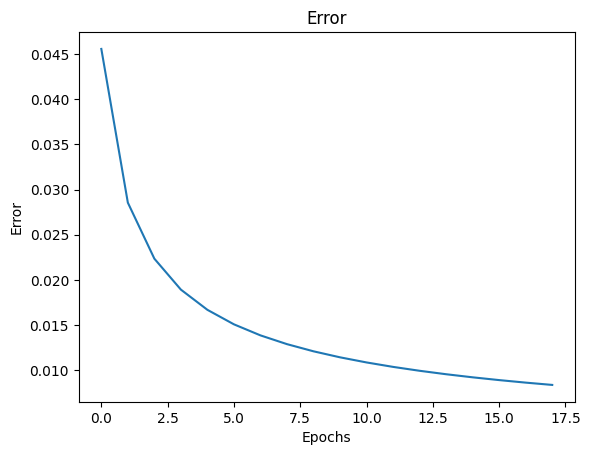

In [7]:
# Plot error
plt.plot(error_list)
plt.title('Error')
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()